# 06 — DSTFS Trend Analysis

**Dave's Simple Trend Following System** — a composite trend indicator combining SMA(50) and HMA(15)
to produce a bias signal from -4 (max bearish) to +4 (max bullish).

The indicator uses 4 bias components:
- **Bias 1**: SMA direction (+1 rising, -1 falling)
- **Bias 2**: HMA direction (+1 rising, -1 falling)
- **Bias 3**: HMA > SMA → +1, else -1
- **Bias 4**: Close > HMA → +1, else -1

Chart layout: candlestick with color-segmented moving averages (top 70%), bias histogram (bottom 30%).

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Connect and Fetch Candle Data

Load config, connect to TastyTrade, and fetch 1 year of daily SPX candles.

In [2]:
from options_analyzer.config import load_config
from options_analyzer.factory import create_providers

config = load_config()
providers = await create_providers(config)
market_data = providers.market_data
print(f"Connected to {providers.provider_name}.")

UNDERLYING = "SPX"
candles = await market_data.get_candles(UNDERLYING, interval="1d", days_back=180)
print(f"Fetched {len(candles)} daily candles for {UNDERLYING}")
print(f"Date range: {candles.timestamps[0]:%Y-%m-%d} to {candles.timestamps[-1]:%Y-%m-%d}")

Connected to TastyTrade (live).


DXLink returned 0 candle events for $SPX, falling back to yfinance


Fetched 123 daily candles for SPX
Date range: 2025-09-11 to 2026-03-09


## 2. Compute DSTFS Indicator

Run the DSTFS computation on the close prices with default parameters (SMA=50, HMA=15).

In [3]:
from options_analyzer.engine.indicators import compute_dstfs

result = compute_dstfs(candles.closes)

# Current signal summary
import numpy as np

latest = len(result.close) - 1
print(f"DSTFS Signal Summary ({candles.timestamps[-1]:%Y-%m-%d})")
print(f"{'='*40}")
print(f"Close:       {result.close[latest]:>10.2f}")
print(f"SMA(50):     {result.sma[latest]:>10.2f}")
print(f"HMA(15):     {result.hma[latest]:>10.2f}")
print(f"{'─'*40}")
print(f"Bias 1 (SMA dir):    {result.bias1[latest]:>+4.0f}")
print(f"Bias 2 (HMA dir):    {result.bias2[latest]:>+4.0f}")
print(f"Bias 3 (HMA>SMA):    {result.bias3[latest]:>+4.0f}")
print(f"Bias 4 (Close>HMA):  {result.bias4[latest]:>+4.0f}")
print(f"{'─'*40}")
print(f"Total Bias:          {result.total_bias[latest]:>+4.0f}")

bias = result.total_bias[latest]
if bias >= 4:
    outlook = "STRONG BULLISH"
elif bias >= 2:
    outlook = "BULLISH"
elif bias == 0:
    outlook = "NEUTRAL"
elif bias >= -2:
    outlook = "BEARISH"
else:
    outlook = "STRONG BEARISH"
print(f"Outlook:             {outlook}")

DSTFS Signal Summary (2026-03-09)
Close:          6795.99
SMA(50):        6900.17
HMA(15):        6795.36
────────────────────────────────────────
Bias 1 (SMA dir):      -1
Bias 2 (HMA dir):      -1
Bias 3 (HMA>SMA):      -1
Bias 4 (Close>HMA):    +1
────────────────────────────────────────
Total Bias:            -2
Outlook:             BEARISH


## 3. DSTFS Candlestick Chart

Two-panel Bloomberg-themed chart:
- **Top**: Candlestick with color-segmented SMA (green/red) and HMA (teal/fuchsia)
- **Bottom**: Bias histogram colored by signal strength

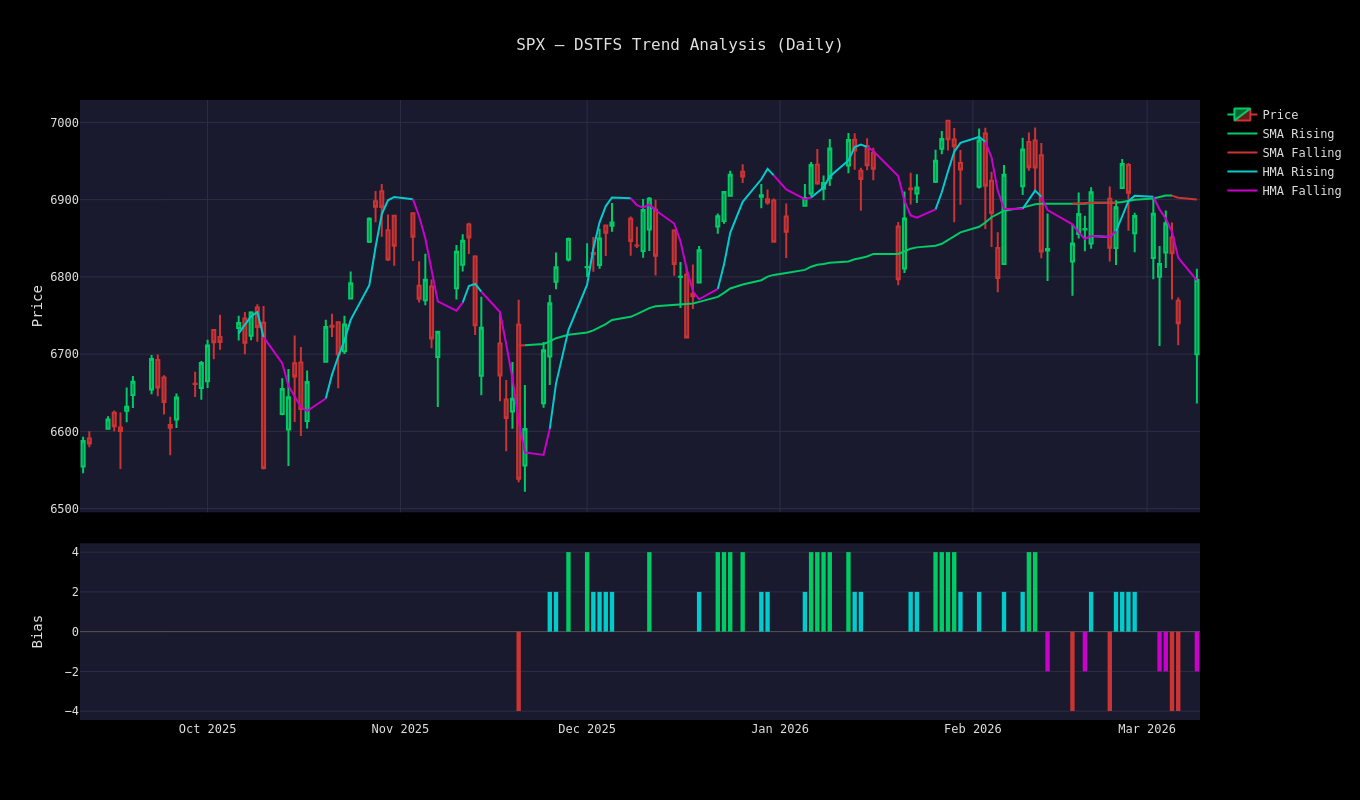

In [5]:
from options_analyzer.visualization.indicator_charts import plot_dstfs_candlestick

fig = plot_dstfs_candlestick(
    result,
    opens=candles.opens,
    highs=candles.highs,
    lows=candles.lows,
    timestamps=candles.timestamps,
    title=f"{UNDERLYING} — DSTFS Trend Analysis (Daily)",
)
fig.update_layout(height=800)
fig.show()

## 4. Standalone Demo (No Provider Needed)

Demonstrate DSTFS with synthetic data — useful for testing without TastyTrade credentials.

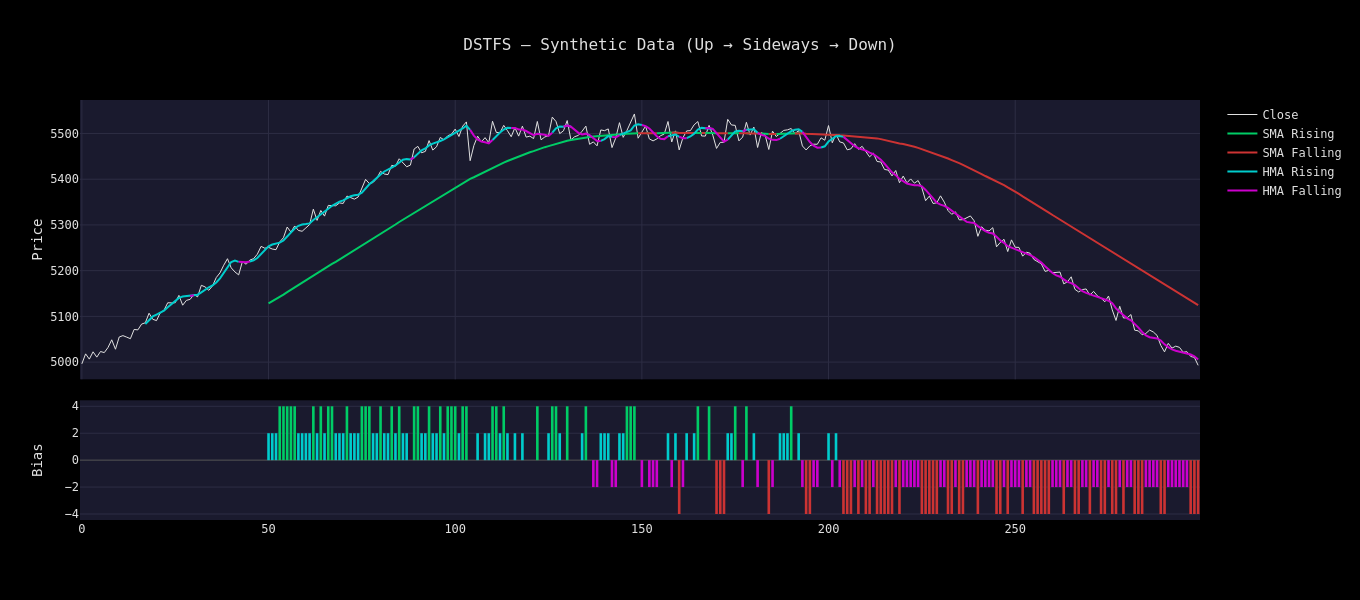

Final bias: -4


In [7]:
import numpy as np

from options_analyzer.engine.indicators import compute_dstfs
from options_analyzer.visualization.indicator_charts import plot_dstfs

# Generate synthetic price data: uptrend → sideways → downtrend
rng = np.random.default_rng(42)
n = 300
trend = np.concatenate([
    np.linspace(5000, 5500, 100),       # uptrend
    np.full(100, 5500) + rng.normal(0, 20, 100),  # sideways
    np.linspace(5500, 5000, 100),       # downtrend
])
noise = rng.normal(0, 10, n)
synthetic_close = trend + noise

result_synth = compute_dstfs(synthetic_close)
fig = plot_dstfs(result_synth, title="DSTFS — Synthetic Data (Up → Sideways → Down)")
fig.update_layout(height=600)
fig.show()

print(f"Final bias: {result_synth.total_bias[-1]:+.0f}")

## 5. Cleanup

In [8]:
await providers.disconnect()
print("Session disconnected.")

Session disconnected.
